# Nesterov como indicador meteorológico auxiliar

Se conserva la adaptación de Nesterov con Open-Meteo y se contrasta con los nuevos niveles de actividad FIRMS. No forma clusters, no es target y no entra automáticamente al modelo.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal,spearmanr
N=Path("data/processed/nesterov/nesterov_departamento_semana_open_meteo_2018_2025.parquet");T=Path("data/processed/modelado/dataset_niveles_actividad_firms.parquet")
n=pd.read_parquet(N);t=pd.read_parquet(T)
for x in (n,t):x["fecha_inicio_semana"]=pd.to_datetime(x.fecha_inicio_semana)
datos=n.merge(t[["departamento","fecha_inicio_semana","cantidad_detecciones","nivel_actividad_firms"]],on=["departamento","fecha_inicio_semana"],validate="one_to_one");assert len(datos)==7923

## Fuente y alcance

La metodología se consultó en la página oficial de INUMET el 26/09/2026. El artefacto existente fue calculado primero a nivel departamento–día con reglas acumulativas y de precipitación. Como usa Open-Meteo y no observaciones INUMET exactas de las 13 h, se denomina **adaptación de Nesterov**, no índice oficial.

## Relación descriptiva con actividad FIRMS

Una asociación no implica causalidad ni capacidad predictiva adicional frente a las variables meteorológicas de origen.

In [2]:
ORDEN=["Sin actividad","Bajo","Moderado","Alto"]
res=datos.groupby("nivel_actividad_firms").nesterov_max_semanal.describe(percentiles=[.25,.5,.75]).reindex(ORDEN);res

,count,mean,std,min,25%,50%,75%,max
nivel_actividad_firms,,,,,,,,
Sin actividad,4967.0,3530.004735,4073.809933,0.000000,1076.210396,2062.164753,4370.217869,33954.128489
Bajo,1237.0,4100.554248,4058.700114,187.915043,1695.486189,2882.258242,4877.404433,41992.754009
Moderado,1266.0,3987.753391,3979.039612,319.023893,1618.285192,2744.768436,4672.833612,38979.338100
Alto,453.0,4362.586380,4408.261720,422.268333,1823.389244,2945.132045,4928.221638,30684.492469


In [3]:
gr=[datos.loc[datos.nivel_actividad_firms.eq(x),"nesterov_max_semanal"] for x in ORDEN];kw=kruskal(*gr);sp=spearmanr(datos.nesterov_max_semanal,datos.cantidad_detecciones);pd.Series({"Kruskal H":kw.statistic,"Kruskal p":kw.pvalue,"Spearman rho":sp.statistic,"Spearman p":sp.pvalue})

Kruskal H       1.973264e+02
Kruskal p       1.595268e-42
Spearman rho    1.545685e-01
Spearman p      1.474238e-43
dtype: float64

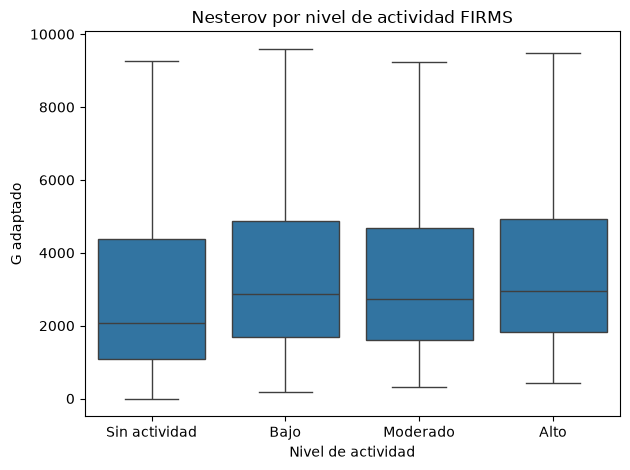

In [4]:
sns.boxplot(data=datos,x="nivel_actividad_firms",y="nesterov_max_semanal",order=ORDEN,showfliers=False);plt.title("Nesterov por nivel de actividad FIRMS");plt.xlabel("Nivel de actividad");plt.ylabel("G adaptado");plt.tight_layout();plt.show()

## Conclusión

Nesterov queda como indicador auxiliar y posible experimento futuro. No altera K-Means ni el target. Su redundancia con temperatura, humedad y precipitación deberá evaluarse mediante una ablación si se incorpora.